In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
''' 1. Na stronie https://www.w3schools.com/python/matplotlib_histograms.asp
 znajduje się skrypt robiący wykres histogramu na podstawie losowo wygenerowanych danych.
 Proszę zmodyfikować skrypt, tak aby:
 - zamiast danych losowych zaciągał dane z pliku "president_heights.csv"
 - generował histogram interaktywnie (otwierając okno z wykresem) (por. przykładowy plik png)
 - wyliczał podstawowe parametry statystyczne z kolumny "height(cm)" - średnią, medianę, kwantyle, max, min, rozstęp, wariancję i odchylenie standardowe.
'''

ZADANIE 1 - Wzrost prezydentów
Średnia: 179.74
Mediana: 182.0
Kwantyl 25%: 174.25
Kwantyl 50%: 182.0
Kwantyl 75%: 183.0
Minimum: 163
Maksimum: 193
Rozstęp: 30
Wariancja: 48.05
Odchylenie std: 6.93


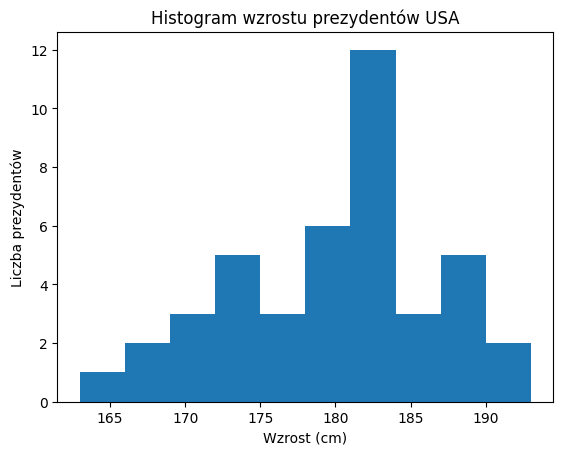

In [3]:
# ZADANIE 1 – president_heights.csv
df1 = pd.read_csv(r'C:\Users\Dell\Documents\Analityka Gospodarcza i Analiza Danych\WSB-courses\analyst-work-environment\data\president_heights.csv')
heights = df1['height(cm)'].to_numpy()

# Statystyki
print("ZADANIE 1 - Wzrost prezydentów")
print("Średnia:", round(np.mean(heights), 2))
print("Mediana:", np.median(heights))
print("Kwantyl 25%:", np.percentile(heights, 25))
print("Kwantyl 50%:", np.percentile(heights, 50))
print("Kwantyl 75%:", np.percentile(heights, 75))
print("Minimum:", np.min(heights))
print("Maksimum:", np.max(heights))
print("Rozstęp:", np.max(heights) - np.min(heights))
print("Wariancja:", round(np.var(heights), 2))
print("Odchylenie std:", round(np.std(heights), 2))

# Histogram
plt.hist(heights)
plt.title('Histogram wzrostu prezydentów USA')
plt.xlabel('Wzrost (cm)')
plt.ylabel('Liczba prezydentów')
plt.show()

In [ ]:

''' 2. Używając przerobionego skryptu z zad 1, dokonaćdalszych modyfikacji, tak aby:
  - skrypt sczytywał plik z danymi "Titanic-Dataset.csv"
  - skrypt usuwał niepotrzebne kolumny ('Name', 'Ticket', 'Cabin')  
  - skrypt dokonywał czyszczenia danych - wyszukiwał a następnie usuwał duplikaty wpisów, wypełniał brakujące pola etc.
  - tworzył histogram na podstawie wieku pasażerów
  - skrypt tworzył wykres słupkowy 3d'''

ZADANIE 2 - Titanic 
Duplikaty przed usunięciem: 0
Duplikaty po usunięciu: 0
Brakujące wartości przed czyszczeniem:
PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
dtype: int64
Brakujące wartości po czyszczeniu:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


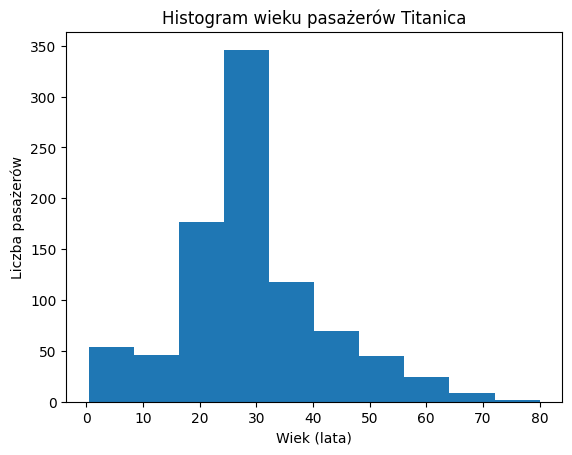

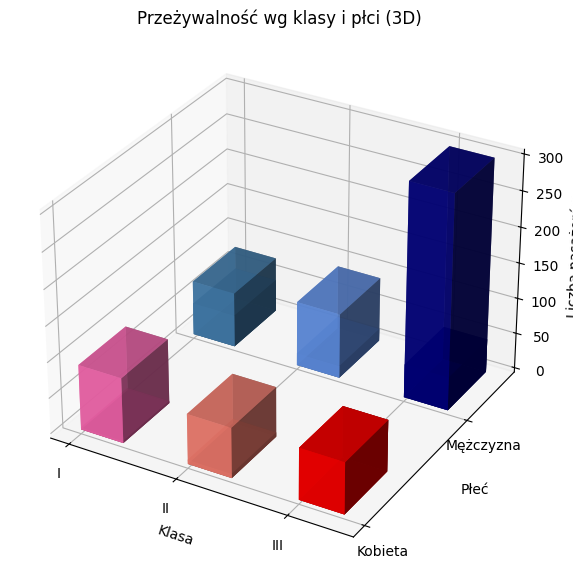

In [5]:
# ZADANIE 2 – Titanic-Dataset.csv
df2 = pd.read_csv(r'C:\Users\Dell\Documents\Analityka Gospodarcza i Analiza Danych\WSB-courses\analyst-work-environment\data\Titanic-Dataset.csv')

# Usunięcie niepotrzebnych kolumn
df2 = df2.drop(columns=['Name', 'Ticket', 'Cabin'])

# Czyszczenie danych
print("ZADANIE 2 - Titanic ")
print("Duplikaty przed usunięciem:", df2.duplicated().sum())
df2 = df2.drop_duplicates()
print("Duplikaty po usunięciu:", df2.duplicated().sum())
print("Brakujące wartości przed czyszczeniem:")
print(df2.isnull().sum())
df2['Age'] = df2['Age'].fillna(df2['Age'].median())
df2['Embarked'] = df2['Embarked'].fillna(df2['Embarked'].mode()[0])
print("Brakujące wartości po czyszczeniu:")
print(df2.isnull().sum())
ages = df2['Age'].to_numpy()

# Histogram wieku
plt.hist(ages)
plt.title('Histogram wieku pasażerów Titanica')
plt.xlabel('Wiek (lata)')
plt.ylabel('Liczba pasażerów')
plt.show()

# Wykres słupkowy 3D
survived_counts = df2.groupby(['Pclass', 'Sex', 'Survived']).size().reset_index(name='Count')
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')
colors = {(1, 'female'): 'hotpink', (1, 'male'): 'steelblue',
          (2, 'female'): 'salmon',   (2, 'male'): 'cornflowerblue',
          (3, 'female'): 'red',      (3, 'male'): 'navy'}
x_pos, y_pos, z_pos, dx, dy, dz, bar_colors = [], [], [], [], [], [], []
for _, row in survived_counts.iterrows():
    x_pos.append(row['Pclass'] - 1)
    y_pos.append(0 if row['Sex'] == 'female' else 1)
    z_pos.append(0)
    dx.append(0.4)
    dy.append(0.4)
    dz.append(row['Count'])
    bar_colors.append(colors.get((row['Pclass'], row['Sex']), 'grey'))
ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz, color=bar_colors, alpha=0.8)
ax.set_xlabel('Klasa')
ax.set_ylabel('Płeć')
ax.set_zlabel('Liczba pasażerów')
ax.set_title('Przeżywalność wg klasy i płci (3D)')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['I', 'II', 'III'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Kobieta', 'Mężczyzna'])
plt.show()